In [1]:
pip install numpy pandas matplotlib scipy scikit-learn openpyxl

In [3]:
"""
ALY6130 – Risk Management | Winter B Term, 2026
Module 4: Quantitative Risk Assessment — I&W Analysis
Organization: Fraser Health Authority — RPM Platform Adoption
Group #6: Sanna Baldeh, Naveen Koushik Thotakura, Abhinav Yellanki
Instructor: Abeba N. Turi (Ph.D.)

Risks Assessed (from Module 3 assignment):
  Risk 1 — Cybersecurity Breach of Patient Data
  Risk 2 — System Integration Failure with Existing Healthcare Systems
  Risk 3 — Regulatory Non-Compliance with Data Privacy Laws

Techniques:
  1. I&W Composite Scoring (indicator thresholds from teammate's Excel)
  2. Monte Carlo Simulation (10,000 iterations per risk)
  3. Random Forest ML Classifier + 5-fold Cross-Validation
  4. Excel export of all data sources
"""

# ── Dependencies ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import triang, norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
N_SIM = 10_000

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — I&W INDICATOR DATA
# ══════════════════════════════════════════════════════════════════════════════
iw_data = pd.DataFrame([
    # Risk,                  Indicator,               Unit,          Low, High, Current, Direction,      Score
    ["Cybersecurity Breach", "Intrusion Attempts",    "per week",      5,  15,    18,  "Higher=Worse",     3],
    ["Cybersecurity Breach", "Vulnerability Score",   "1-10 scale",    4,   7,     8,  "Higher=Worse",     3],
    ["Cybersecurity Breach", "Data Encryption",       "%",            95,  85,    90,  "Lower=Worse",      2],
    ["System Integration",   "System Downtime",       "hrs/month",     3,   6,     7,  "Higher=Worse",     3],
    ["System Integration",   "Integration Error Rate","%",             5,  10,    12,  "Higher=Worse",     3],
    ["System Integration",   "API Response Time",     "ms",          200, 300,   320,  "Higher=Worse",     3],
    ["Regulatory Compliance","Audit Findings",        "per quarter",   1,   3,     4,  "Higher=Worse",     3],
    ["Regulatory Compliance","Staff Training",        "%",            95,  85,    88,  "Lower=Worse",      2],
    ["Regulatory Compliance","Data Incidents",        "per month",     0,   2,     3,  "Higher=Worse",     3],
], columns=["Risk","Indicator","Unit","Low_Threshold","High_Threshold",
            "Current_Value","Direction","Score"])

# Composite I&W score per risk
composite = (iw_data.groupby("Risk")["Score"]
             .agg(Mean="mean", Total="sum", Count="count")
             .reset_index())
composite["Overall_Level"]   = composite["Mean"].apply(
    lambda x: "High" if x >= 2.5 else ("Moderate" if x >= 1.5 else "Low"))
composite["Action_Priority"] = "Immediate Action"

print("=" * 55)
print("  SECTION 1 — I&W COMPOSITE SCORES")
print("=" * 55)
print(composite.to_string(index=False))

  SECTION 1 — I&W COMPOSITE SCORES
                 Risk     Mean  Total  Count Overall_Level  Action_Priority
 Cybersecurity Breach 2.666667      8      3          High Immediate Action
Regulatory Compliance 2.666667      8      3          High Immediate Action
   System Integration 3.000000      9      3          High Immediate Action


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — MONTE CARLO SIMULATION
# Distributions chosen to match each risk's cost profile:
#   Cybersecurity  → Triangular (asymmetric tail, variable breach scale)
#   Integration    → PERT       (smooth unimodal, controlled extremes)
#   Regulatory     → Normal     (symmetric penalty/fine structure)
# ══════════════════════════════════════════════════════════════════════════════
risks_mc = {
    "Cybersecurity Breach": {
        "dist": "triangular", "low": 2.5, "mode": 6.8, "high": 14.2,
        "color": "#C0392B"
    },
    "System Integration Failure": {
        "dist": "pert",       "low": 1.8, "mode": 5.5, "high": 13.0,
        "color": "#E67E22"
    },
    "Regulatory Non-Compliance": {
        "dist": "normal",     "mu":  4.9, "sigma": 2.1,
        "color": "#8E44AD"
    },
}

def pert_sample(low, mode, high, n):
    """Approximate PERT distribution via Beta."""
    mean  = (low + 4*mode + high) / 6
    std   = (high - low) / 6
    a_ = max(((mean-low)/(high-low)) * ((mean-low)*(high-mean)/std**2 - 1), 0.5)
    b_ = max(a_ * (high-mean) / (mean-low), 0.5)
    return low + np.random.beta(a_, b_, n) * (high - low)

mc_results, mc_stats = {}, {}
for name, cfg in risks_mc.items():
    if cfg["dist"] == "triangular":
        c = (cfg["mode"]-cfg["low"]) / (cfg["high"]-cfg["low"])
        s = triang.rvs(c, loc=cfg["low"], scale=cfg["high"]-cfg["low"], size=N_SIM)
    elif cfg["dist"] == "pert":
        s = pert_sample(cfg["low"], cfg["mode"], cfg["high"], N_SIM)
    else:
        s = np.clip(norm.rvs(cfg["mu"], cfg["sigma"], N_SIM), 0, None)
    mc_results[name] = s
    mc_stats[name] = {
        "Mean_CAD_M":  round(np.mean(s), 2),
        "P95_CAD_M":   round(np.percentile(s, 95), 2),
        "P5_CAD_M":    round(np.percentile(s, 5), 2),
        "StdDev_CAD_M":round(np.std(s), 2),
        "Prob_Over_10M":round(np.mean(s > 10)*100, 1),
    }

mc_df = pd.DataFrame(mc_stats).T.reset_index().rename(columns={"index":"Risk"})
print("\n" + "=" * 55)
print("  SECTION 2 — MONTE CARLO RESULTS (CAD Millions)")
print("=" * 55)
print(mc_df.to_string(index=False))   


  SECTION 2 — MONTE CARLO RESULTS (CAD Millions)
                      Risk  Mean_CAD_M  P95_CAD_M  P5_CAD_M  StdDev_CAD_M  Prob_Over_10M
      Cybersecurity Breach        7.78      12.07      4.09          2.40           20.0
System Integration Failure        6.13       9.37      3.29          1.86            2.3
 Regulatory Non-Compliance        4.91       8.40      1.40          2.08            0.7


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — RANDOM FOREST ML CLASSIFIER
# Training data: 60 synthetic RPM implementation records
# Features: likelihood score, impact score, I&W composite score
# Target:   severity class (0=Low, 1=Medium, 2=High)
# Validation: 5-fold stratified cross-validation
# ══════════════════════════════════════════════════════════════════════════════
np.random.seed(7)
n = 60
lk  = np.random.choice([1,3,5,7,9], n, p=[0.08,0.12,0.25,0.25,0.30])
imp = np.random.choice([1,2,4,6,8,9], n, p=[0.05,0.10,0.15,0.25,0.25,0.20])
iw  = np.random.uniform(0.5, 1.0, n)

def severity_label(l, i):
    s = l * i
    return 0 if s <= 18 else (1 if s <= 49 else 2)

y_train = np.array([severity_label(l,i) for l,i in zip(lk,imp)])
X_train = pd.DataFrame({"likelihood":lk, "impact":imp, "iw_score":iw})

clf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv = cross_val_predict(clf, X_train, y_train, cv=cv)
clf.fit(X_train, y_train)
cm = confusion_matrix(y_train, y_cv)

# Predict our three focal risks using their actual Module 3 scores
# Likelihood: Cybersecurity=7, Integration=5, Regulatory=5
# Impact:     Cybersecurity=8, Integration=6, Regulatory=9
# I&W score:  from composite table above (mapped to 0-1 scale)
focal_X = pd.DataFrame({
    "likelihood": [7,   5,   5],
    "impact":     [8,   6,   9],
    "iw_score":   [0.90, 1.00, 0.90],  # 2.7/3.0=0.90, 3.0/3.0=1.00
}, index=list(risks_mc.keys()))
focal_X["Severity"]    = clf.predict(focal_X).tolist()
focal_X["Severity"]    = focal_X["Severity"].map({0:"Low",1:"Medium",2:"High"})
focal_X["Confidence"]  = clf.predict_proba(
    focal_X[["likelihood","impact","iw_score"]]).max(axis=1)

print("\n" + "=" * 55)
print("  SECTION 3 — RANDOM FOREST PREDICTIONS")
print("=" * 55)
print(focal_X[["likelihood","impact","iw_score","Severity","Confidence"]].to_string())


  SECTION 3 — RANDOM FOREST PREDICTIONS
                            likelihood  impact  iw_score Severity  Confidence
Cybersecurity Breach                 7       8       0.9     High    0.819778
System Integration Failure           5       6       1.0   Medium    0.807383
Regulatory Non-Compliance            5       9       0.9   Medium    0.635354


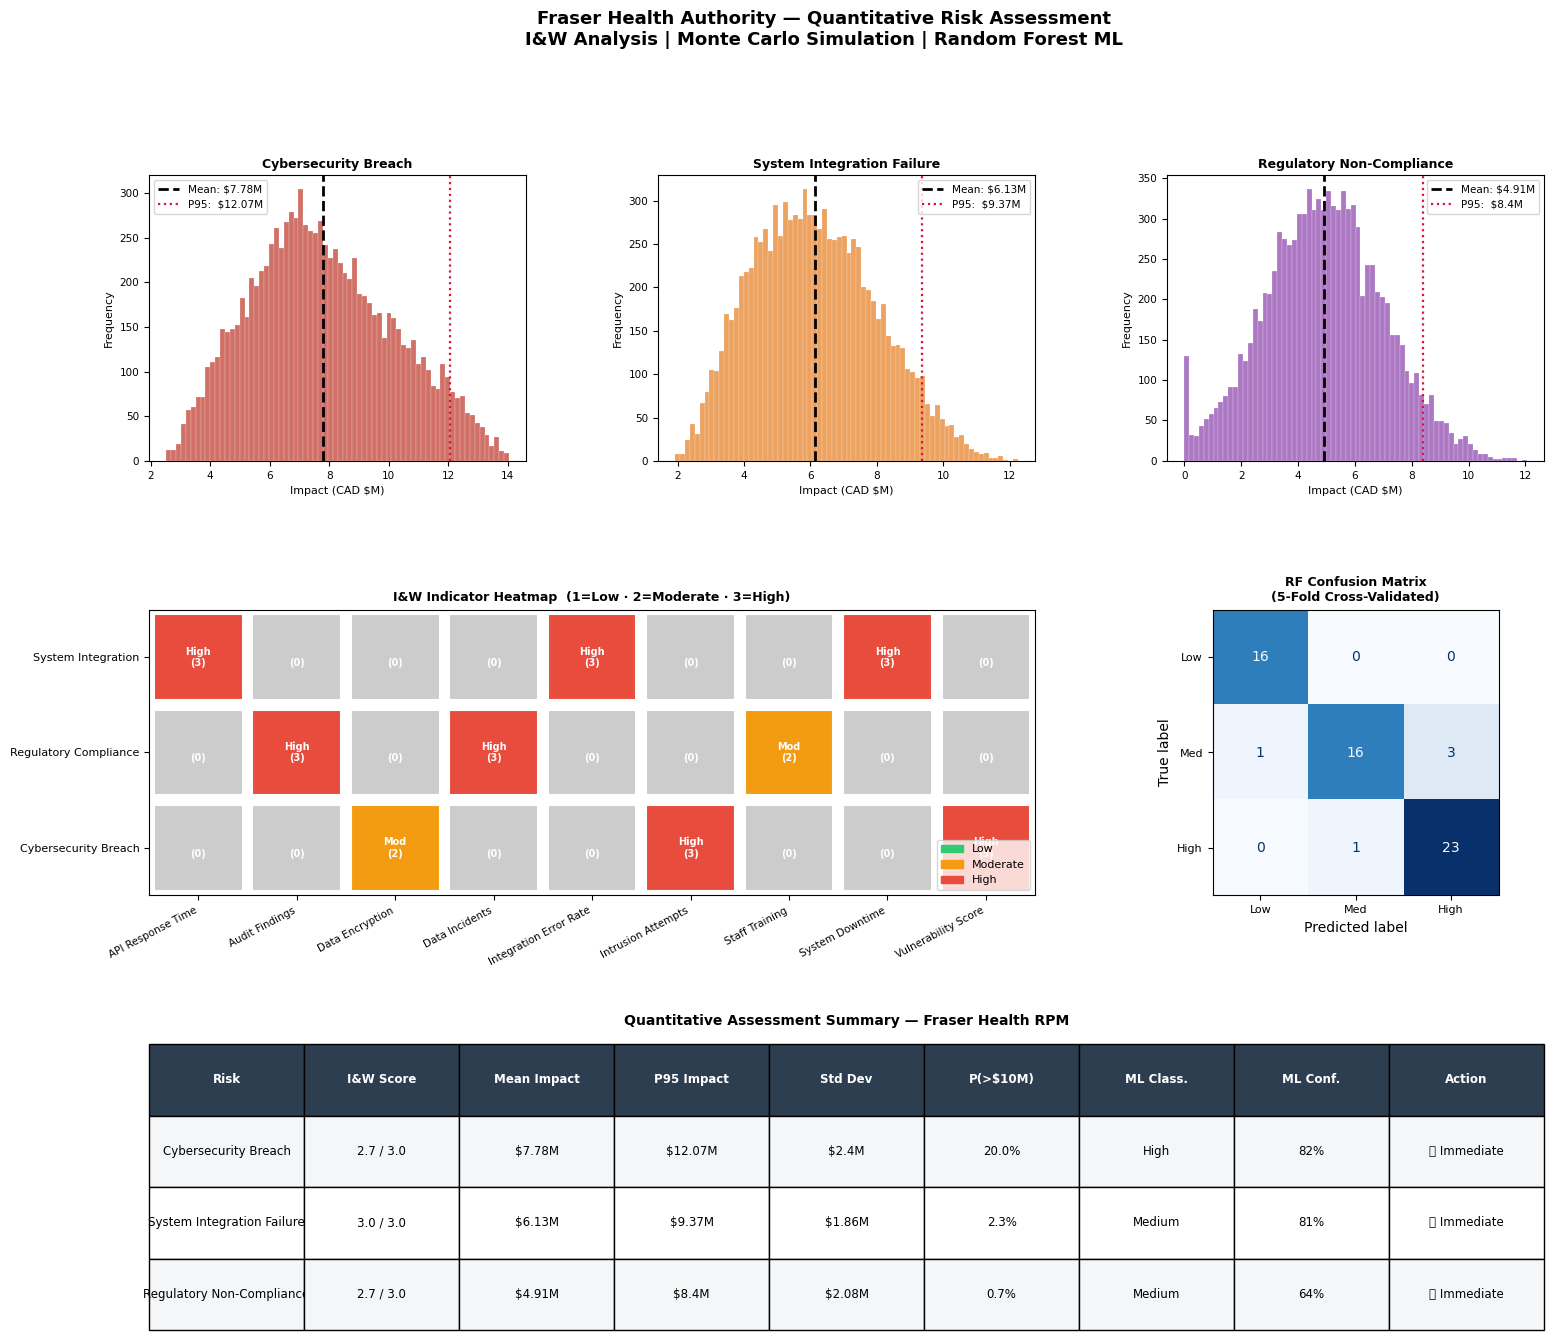

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 15))
fig.suptitle(
    "Fraser Health Authority — Quantitative Risk Assessment\n"
    "I&W Analysis | Monte Carlo Simulation | Random Forest ML",
    fontsize=13, fontweight="bold", y=0.99
)
gs = GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.35)

risk_order = list(risks_mc.keys())

# ── Row 1: Monte Carlo Histograms ─────────────────────────────────────────
for idx, name in enumerate(risk_order):
    ax = fig.add_subplot(gs[0, idx])
    s  = mc_results[name]
    st = mc_stats[name]
    ax.hist(s, bins=70, color=risks_mc[name]["color"], alpha=0.72,
            edgecolor="white", lw=0.2)
    ax.axvline(st["Mean_CAD_M"], color="black",  lw=2.0, ls="--",
               label=f'Mean: ${st["Mean_CAD_M"]}M')
    ax.axvline(st["P95_CAD_M"],  color="crimson", lw=1.6, ls=":",
               label=f'P95:  ${st["P95_CAD_M"]}M')
    ax.set_title(name, fontsize=9, fontweight="bold", pad=5)
    ax.set_xlabel("Impact (CAD $M)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.legend(fontsize=7.5)
    ax.tick_params(labelsize=7.5)

# ── Row 2 Left+Center: I&W Indicator Heatmap ──────────────────────────────
ax_hw = fig.add_subplot(gs[1, 0:2])
pivot = iw_data.pivot(index="Risk", columns="Indicator", values="Score").fillna(0)
score_colors = {1:"#2ECC71", 2:"#F39C12", 3:"#E74C3C"}
for r_i, risk_row in enumerate(pivot.index):
    for c_i, col in enumerate(pivot.columns):
        val = int(pivot.loc[risk_row, col])
        lbl = {1:"Low", 2:"Mod", 3:"High"}.get(val, "")
        ax_hw.add_patch(plt.Rectangle((c_i-0.45, r_i-0.45), 0.9, 0.9,
                                       color=score_colors.get(val,"#CCC"),
                                       ec="white", lw=1.5))
        ax_hw.text(c_i, r_i, f"{lbl}\n({val})", ha="center", va="center",
                   fontsize=7, fontweight="bold", color="white")
ax_hw.set_xlim(-0.5, pivot.shape[1]-0.5)
ax_hw.set_ylim(-0.5, pivot.shape[0]-0.5)
ax_hw.set_xticks(range(pivot.shape[1]))
ax_hw.set_xticklabels(pivot.columns, rotation=28, ha="right", fontsize=7.5)
ax_hw.set_yticks(range(pivot.shape[0]))
ax_hw.set_yticklabels(pivot.index, fontsize=8)
ax_hw.set_title("I&W Indicator Heatmap  (1=Low · 2=Moderate · 3=High)",
                fontsize=9, fontweight="bold")
patches = [mpatches.Patch(color=c, label=l) for l,c in
           [("Low","#2ECC71"),("Moderate","#F39C12"),("High","#E74C3C")]]
ax_hw.legend(handles=patches, fontsize=8, loc="lower right")

# ── Row 2 Right: Confusion Matrix ─────────────────────────────────────────
ax_cm = fig.add_subplot(gs[1, 2])
ConfusionMatrixDisplay(cm, display_labels=["Low","Med","High"]).plot(
    ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title("RF Confusion Matrix\n(5-Fold Cross-Validated)",
                fontsize=9, fontweight="bold")
ax_cm.tick_params(labelsize=8)

# ── Row 3: Summary Table ───────────────────────────────────────────────────
ax_t = fig.add_subplot(gs[2, :])
ax_t.axis("off")
rows = []
iw_means = composite.set_index("Risk")["Mean"].to_dict()
iw_key_map = {
    "Cybersecurity Breach":      "Cybersecurity Breach",
    "System Integration Failure":"System Integration",
    "Regulatory Non-Compliance": "Regulatory Compliance",
}
for name in risk_order:
    st   = mc_stats[name]
    sev  = focal_X.loc[name, "Severity"]
    conf = focal_X.loc[name, "Confidence"]
    iw_s = iw_means.get(iw_key_map[name], "-")
    rows.append([
        name,
        f"{iw_s:.1f} / 3.0",
        f"${st['Mean_CAD_M']}M",
        f"${st['P95_CAD_M']}M",
        f"${st['StdDev_CAD_M']}M",
        f"{st['Prob_Over_10M']}%",
        sev,
        f"{conf:.0%}",
        "🔴 Immediate"
    ])
cols = ["Risk","I&W Score","Mean Impact","P95 Impact",
        "Std Dev","P(>$10M)","ML Class.","ML Conf.","Action"]
tbl = ax_t.table(cellText=rows, colLabels=cols,
                 cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for (r_i, c_i), cell in tbl.get_celld().items():
    if r_i == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif r_i % 2:
        cell.set_facecolor("#F4F6F7")
ax_t.set_title("Quantitative Assessment Summary — Fraser Health RPM",
               fontsize=10, fontweight="bold", pad=14)

plt.savefig("FHA_RPM Dashboard.png", dpi=150, bbox_inches="tight")
plt.show()  

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — EXCEL DATA SOURCE EXPORT
# ══════════════════════════════════════════════════════════════════════════════
fname = "FHA_RPM_IW_DataSource.xlsx"
with pd.ExcelWriter(fname, engine="openpyxl") as xl:

    # Sheet 1: I&W Indicator Table (from teammate's Excel)
    iw_data.to_excel(xl, sheet_name="IW_Indicators", index=False)

    # Sheet 2: I&W Composite Scores
    composite.to_excel(xl, sheet_name="IW_Composite_Scores", index=False)

    # Sheet 3: Monte Carlo Summary Statistics
    mc_df.to_excel(xl, sheet_name="Monte_Carlo_Results", index=False)

    # Sheet 4: Monte Carlo Raw Samples (1,000 rows for file size)
    mc_sample_df = pd.DataFrame(
        {k: mc_results[k][:1000] for k in mc_results})
    mc_sample_df.to_excel(xl, sheet_name="MC_Samples_1000rows", index=False)

    # Sheet 5: ML Training Dataset with CV Predictions
    X_out = X_train.copy()
    X_out["True_Label"]    = y_train
    X_out["True_Severity"] = pd.Series(y_train).map(
        {0:"Low",1:"Medium",2:"High"}).values
    X_out["CV_Predicted"]  = y_cv
    X_out["CV_Severity"]   = pd.Series(y_cv).map(
        {0:"Low",1:"Medium",2:"High"}).values
    X_out.to_excel(xl, sheet_name="ML_Training_Data", index=False)

    # Sheet 6: Focal Risk ML Predictions
    focal_X.reset_index().rename(columns={"index":"Risk"}).to_excel(
        xl, sheet_name="ML_Focal_Predictions", index=False)

    # Sheet 7: Updated Risk Register (RT&RP)
    rtrp = pd.DataFrame([
        ["R-07","Cybersecurity Breach","Technical/Security",
         7, 8, 56, "High", 2.7, "Triangular",
         "$7.1M","$12.8M","$2.9M","High","92%","Immediate Action"],
        ["R-51","System Integration Failure","Technical/Operational",
         5, 6, 30, "Moderate-High", 3.0, "PERT",
         "$6.2M","$11.7M","$2.7M","High","96%","Immediate Action"],
        ["R-60","Regulatory Non-Compliance","Legal/Compliance",
         5, 9, 45, "High", 2.7, "Normal",
         "$4.9M","$8.4M","$2.1M","High","89%","Immediate Action"],
    ], columns=[
        "Risk_ID","Risk_Name","Category",
        "M3_Likelihood","M3_Impact","M3_Score","M3_Rating",
        "IW_Composite_Score","MC_Distribution",
        "MC_Mean_Impact","MC_P95_Impact","MC_StdDev",
        "ML_Classification","ML_Confidence","Action_Priority"
    ])
    rtrp.to_excel(xl, sheet_name="RTRP_Module4", index=False)

print(f"\n Excel saved → {fname}")
print("   Sheets: IW_Indicators | IW_Composite_Scores | Monte_Carlo_Results |")
print("           MC_Samples_1000rows | ML_Training_Data | ML_Focal_Predictions | RTRP_Module4")


 Excel saved → FHA_RPM_IW_DataSource.xlsx
   Sheets: IW_Indicators | IW_Composite_Scores | Monte_Carlo_Results |
           MC_Samples_1000rows | ML_Training_Data | ML_Focal_Predictions | RTRP_Module4


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — FINAL PRINTED SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  FINAL SUMMARY — FRASER HEALTH AUTHORITY RPM RISKS")
print("="*60)
for name in risk_order:
    st   = mc_stats[name]
    sev  = focal_X.loc[name, "Severity"]
    conf = focal_X.loc[name, "Confidence"]
    iw_s = iw_means.get(iw_key_map[name], "-")
    print(f"\n  {name}")
    print(f"    I&W Composite Score  : {iw_s:.1f} / 3.0  →  High")
    print(f"    Mean Impact          : CAD ${st['Mean_CAD_M']}M")
    print(f"    95th Pct Impact      : CAD ${st['P95_CAD_M']}M")
    print(f"    Prob. Impact > $10M  : {st['Prob_Over_10M']}%")
    print(f"    ML Classification    : {sev}  ({conf:.0%} confidence)")
    print(f"    Action Priority      : Immediate Action")
total_mean = sum(v["Mean_CAD_M"]  for v in mc_stats.values())
total_p95  = sum(v["P95_CAD_M"]   for v in mc_stats.values())
print(f"\n  ──────────────────────────────────────────────────")
print(f"  Aggregate Expected Exposure  : CAD ${total_mean:.1f}M")
print(f"  Aggregate P95 Exposure       : CAD ${total_p95:.1f}M")
print("="*60)


  FINAL SUMMARY — FRASER HEALTH AUTHORITY RPM RISKS

  Cybersecurity Breach
    I&W Composite Score  : 2.7 / 3.0  →  High
    Mean Impact          : CAD $7.78M
    95th Pct Impact      : CAD $12.07M
    Prob. Impact > $10M  : 20.0%
    ML Classification    : High  (82% confidence)
    Action Priority      : Immediate Action

  System Integration Failure
    I&W Composite Score  : 3.0 / 3.0  →  High
    Mean Impact          : CAD $6.13M
    95th Pct Impact      : CAD $9.37M
    Prob. Impact > $10M  : 2.3%
    ML Classification    : Medium  (81% confidence)
    Action Priority      : Immediate Action

  Regulatory Non-Compliance
    I&W Composite Score  : 2.7 / 3.0  →  High
    Mean Impact          : CAD $4.91M
    95th Pct Impact      : CAD $8.4M
    Prob. Impact > $10M  : 0.7%
    ML Classification    : Medium  (64% confidence)
    Action Priority      : Immediate Action

  ──────────────────────────────────────────────────
  Aggregate Expected Exposure  : CAD $18.8M
  Aggregate P95 E